#**Uber Fare Prediction (Regression)**
**SIBI SUBHASH 2023BCSE07AED160**


Importing Required Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

Loading the Uber Dataset

In [7]:
df=pd.read_csv('/content/uber.csv')

Exploratory Data Analysis (EDA)

In [8]:
print(df.head())
print(df.shape)
df.info()
df.describe()

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647                1  
3         

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Dropping Irrelevant Columns

In [9]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'key' in df.columns:
    df.drop('key', axis=1, inplace=True)

Feature Engineering from Pickup Date-Time

In [10]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["hour"] = df["pickup_datetime"].dt.hour
df["day"] = df["pickup_datetime"].dt.day
df["month"] = df["pickup_datetime"].dt.month
df["weekday"] = df["pickup_datetime"].dt.weekday
df = df.drop(columns=["pickup_datetime"])

In [11]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5,3
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7,4
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6,4
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8,3


Filtering Invalid Fare Values and Latitude Longitude

In [12]:
df.dropna(inplace=True)
df = df[df["fare_amount"] > 0]
df = df[df["fare_amount"] < 200]
df = df[
    (df["pickup_longitude"] > -180) &
    (df["pickup_longitude"] < 180) &
    (df["dropoff_longitude"] > -180) &
    (df["dropoff_longitude"] < 180)
]
df = df[
(df["pickup_latitude"] > -90) &
(df["pickup_latitude"] < 90) &
(df["dropoff_latitude"] > -90) &
(df["dropoff_latitude"] < 90)
]
df = df[df["passenger_count"] > 0]


Correlation Analysis

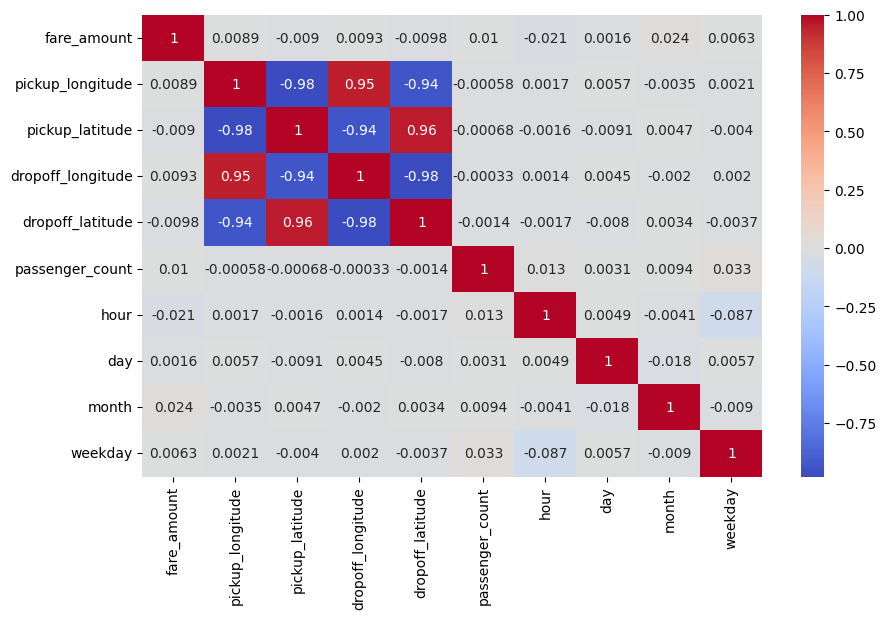

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Calculating Trip Distance using Haversine Formula

Scatter Plot: Distance vs Fare

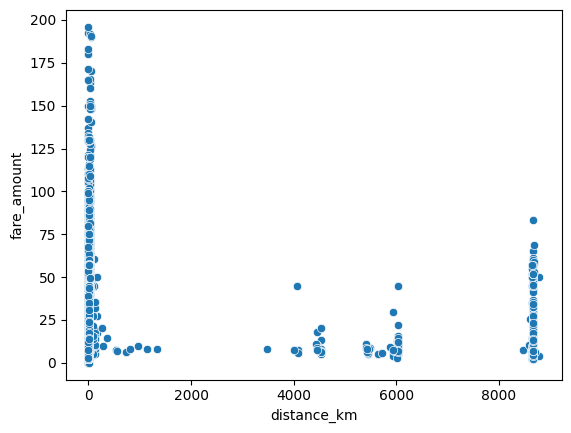

In [14]:
import numpy as np

R = 6371  # Earth radius in km

lat1 = np.radians(df["pickup_latitude"])
lon1 = np.radians(df["pickup_longitude"])
lat2 = np.radians(df["dropoff_latitude"])
lon2 = np.radians(df["dropoff_longitude"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = R * c
sns.scatterplot(x=df["distance_km"], y=df["fare_amount"])
plt.show()

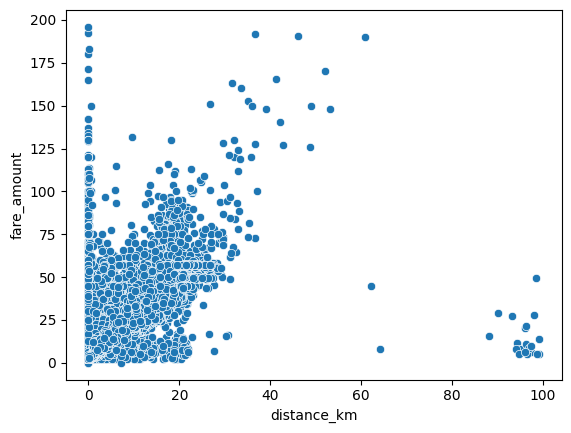

In [15]:
df = df[df["distance_km"] < 100]
sns.scatterplot(x=df["distance_km"], y=df["fare_amount"])
plt.show()

In [16]:
df = df[(df["distance_km"] > 0.1) & (df["distance_km"] < 50)]
df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 150)]

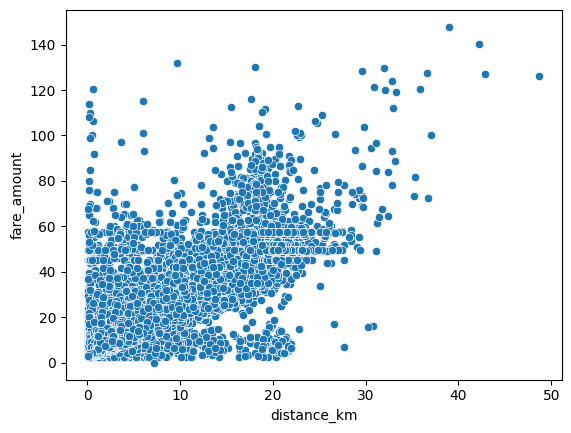

In [17]:
sns.scatterplot(x=df["distance_km"], y=df["fare_amount"])
plt.show()

In [18]:
X = df.drop("fare_amount", axis=1)
y = df["fare_amount"]

Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [22]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [23]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

Model Evaluation Function

In [24]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

In [25]:
rmse_lr, r2_lr = evaluate(y_test, pred_lr)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 4.091924682920245
Linear Regression R2: 0.8077545837044144


In [26]:
rmse_rf, r2_rf = evaluate(y_test, pred_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 3.547439194570384
Random Forest R2: 0.8555123754255227


In [27]:
rmse_xgb, r2_xgb = evaluate(y_test, pred_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 3.501530598816765
XGBoost R2: 0.85922790214942


In [28]:
from sklearn.model_selection import cross_val_score

In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf,X,y,cv=5,scoring="r2")

print("Cross Validation Scores:", scores)
print("Average R2 Score:", scores.mean())

Cross Validation Scores: [0.8606055  0.86294166 0.86049136 0.85112326 0.86063327]
Average R2 Score: 0.8591590117170421


In [30]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42)

scores = cross_val_score(xgb,X,y,cv=5,scoring="r2")

print("XGBoost CV Scores:", scores)
print("Average R2:", scores.mean())

XGBoost CV Scores: [0.86287971 0.86541235 0.86625949 0.85530355 0.86697211]
Average R2: 0.8633654429917721


In [31]:
import joblib
joblib.dump(xgb, "uber_fare_model.pkl")
from google.colab import files
files.download("uber_fare_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>